In [20]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [21]:
data_path = os.path.join(*Path.cwd().parts[:-1],"data")

**Read in data from csv files**

In [22]:
df = pd.DataFrame()
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        temp_df = pd.read_csv(file_path)
        df = pd.concat([df, temp_df], ignore_index=True)
len(df)

4440384

In [23]:
df.head(10)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,2023-01-31 14:00:01,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,2023-01-31 14:00:02,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,2023-01-31 14:00:03,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,2023-01-31 14:00:04,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,2023-01-31 14:00:05,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250
5,2023-01-31 14:00:06,0.000205,0.000166,0.000149,19.791374,19.863214,19.958219,19.611355,19.782754,19.910986,19.686506,19.866983,19.779079,19.822659,20.084014,20.555750,56.515500
6,2023-01-31 14:00:07,0.000207,0.000166,0.000149,19.791391,19.863192,19.958266,19.611362,19.782839,19.910973,19.686427,19.866940,19.779043,19.822784,20.084038,20.554000,56.531250
7,2023-01-31 14:00:08,0.000204,0.000166,0.000149,19.791472,19.863189,19.958201,19.611344,19.782866,19.910877,19.686598,19.866845,19.779098,19.822806,20.084124,20.555750,56.514750
8,2023-01-31 14:00:09,0.000206,0.000166,0.000148,19.791444,19.863215,19.958139,19.611246,19.782896,19.910850,19.686901,19.866846,19.779024,19.822787,20.084177,20.551750,56.517125
9,2023-01-31 14:00:10,0.000205,0.000166,0.000149,19.791392,19.863227,19.958176,19.611274,19.782966,19.910889,19.687056,19.866805,19.778983,19.822764,20.084140,20.552250,56.520000


Convert date to timestamp.

In [24]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S')
df['Date'] = df['Date'].astype('int64')//10**6

In [25]:
df.head(5)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,1675173601,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,1675173602,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,1675173603,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,1675173604,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,1675173605,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250


In [26]:
df = df.sort_values('Date').reset_index(drop=True)

Determine chunks of data that are uninterrupted.

In [27]:
times = df['Date'].values
best_start, best_end = 0, 0
last_idx = 0
for idx in range(1, len(times)):
    if times[idx] - times[idx - 1] > 1:
        if idx - last_idx > best_end - best_start:
            best_start, best_end = last_idx, idx
            print(f'New longest run len: {best_end - best_start}')
        last_idx = idx
if len(times) - last_idx > best_end - best_start:
    best_start, best_end = last_idx, len(times)
    print(f'New longest run len: {best_end - best_start}')
uninterrupted_df = df[best_start:best_end]

New longest run len: 269
New longest run len: 4334
New longest run len: 7491
New longest run len: 14438
New longest run len: 17837
New longest run len: 70368
New longest run len: 70795
New longest run len: 90599
New longest run len: 252000
New longest run len: 739720
New longest run len: 746265


In [28]:
uninterrupted_df.drop(columns='Altitude [m]', inplace=True)
uninterrupted_df.head(10)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C]
1967042,1678873335,-0.000255,0.000015,0.000027,20.343941,20.452242,20.536662,20.454394,20.840455,21.149750,20.576104,20.980258,20.775696,21.235692,21.021573,20.779997
1967043,1678873336,-0.000258,0.000015,0.000026,20.344488,20.452119,20.536670,20.454457,20.839291,21.149834,20.576155,20.980214,20.775706,21.235638,21.021625,20.784550
1967044,1678873337,-0.000258,0.000015,0.000026,20.344734,20.452174,20.536654,20.454648,20.838908,21.149494,20.576266,20.979903,20.775798,21.234698,21.021522,20.789950
1967045,1678873338,-0.000257,0.000015,0.000026,20.344861,20.452265,20.536711,20.454957,20.838893,21.149110,20.576554,20.979604,20.775955,21.233754,21.021452,20.790000
1967046,1678873339,-0.000258,0.000014,0.000026,20.344875,20.452364,20.536803,20.455168,20.838885,21.148781,20.576778,20.979453,20.775926,21.232783,21.021507,20.790000
1967047,1678873340,-0.000256,0.000014,0.000026,20.344939,20.452622,20.536942,20.455435,20.839091,21.148548,20.577267,20.979315,20.775972,21.231861,21.021581,20.787250
1967048,1678873341,-0.000257,0.000014,0.000027,20.345094,20.452741,20.537126,20.455811,20.839236,21.148320,20.577427,20.979191,20.776113,21.230930,21.021564,20.788750
1967049,1678873342,-0.000258,0.000015,0.000026,20.345158,20.452818,20.537104,20.456032,20.839469,21.147980,20.577619,20.978906,20.776156,21.230071,21.021545,20.792625
1967050,1678873343,-0.000257,0.000014,0.000027,20.345339,20.452928,20.537181,20.456352,20.839468,21.147686,20.577954,20.978667,20.776228,21.229101,21.021564,20.801875
1967051,1678873344,-0.000258,0.000014,0.000026,20.345431,20.453102,20.537346,20.456736,20.839564,21.147560,20.578284,20.978576,20.776275,21.228209,21.021675,20.807750


In [29]:
uninterrupted_df["error_array"] = uninterrupted_df[[ "x [m/s2]", "y [m/s2]", "z [m/s2]"]].values.tolist()
uninterrupted_df["error_array"].head(10)

1967042    [1.523687473304808e-05, 2.6551772364558212e-05...
1967043    [1.4840056551229913e-05, 2.6494954182740057e-0...
1967044    [1.4779556551229904e-05, 2.6426454182740016e-0...
1967045    [1.455005655122991e-05, 2.6461954182740026e-05...
1967046    [1.4421556551229905e-05, 2.629295418274004e-05...
1967047    [1.4431056551229914e-05, 2.6004454182740053e-0...
1967048    [1.4433556551229933e-05, 2.662845418274003e-05...
1967049    [1.486405655122992e-05, 2.6042954182740062e-05...
1967050    [1.416705655122991e-05, 2.660895418274003e-05,...
1967051    [1.3704556551229912e-05, 2.6328454182740055e-0...
Name: error_array, dtype: object

In [30]:
uninterrupted_df.drop(["x [m/s2]", "y [m/s2]", "z [m/s2]"], axis=1, inplace=True)

In [31]:
t1 = uninterrupted_df['Date'].iloc[0]
uninterrupted_df['Date'] = uninterrupted_df['Date'] - t1

In [32]:
uninterrupted_df.head(2)

,Date,T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],error_array
1967042,0,20.343941,20.452242,20.536662,20.454394,20.840455,21.149750,20.576104,20.980258,20.775696,21.235692,21.021573,20.779997,"[1.523687473304808e-05, 2.6551772364558212e-05..."
1967043,1,20.344488,20.452119,20.536670,20.454457,20.839291,21.149834,20.576155,20.980214,20.775706,21.235638,21.021625,20.784550,"[1.4840056551229913e-05, 2.6494954182740057e-0..."


Try training LSTMs with different features.

In [33]:
temperature_cols = [
    "T z [C]",
    "T x [C]",
    "T y [C]"
]

"""
    "bottom x1 side [C]",
    "x sensor face [C]",
    "y sensor face [C]",
    "bottom x2 side [C]",
    "x elect face [C]",
    "y ACQ face [C]",
    "top [C]",
    "inside air [C]",
    "external [C]"
"""

target_col = ["error_array"]

In [34]:
model_df = uninterrupted_df.copy()
model_df = model_df.sort_values("Date").reset_index(drop=True)

# Temperature change rates
for col in temperature_cols:
    model_df[f"{col}_dT"] = model_df[col].diff()

# Spatial temperature summaries
model_df["temp_mean"] = model_df[temperature_cols].mean(axis=1)
model_df["temp_std"] = model_df[temperature_cols].std(axis=1)
model_df["temp_range"] = (
    model_df[temperature_cols].max(axis=1)
    - model_df[temperature_cols].min(axis=1)
)

# Physically meaningful temperature differences
model_df["x_sensor_diff"] = (
    model_df["x sensor face [C]"]
    - model_df["x elect face [C]"]
)

model_df["y_sensor_diff"] = (
    model_df["y sensor face [C]"]
    - model_df["y ACQ face [C]"]
)

# Temperature lags
temperature_lags = [1, 2, 5, 10, 30, 60]

for lag in temperature_lags:
    for col in temperature_cols:
        model_df[f"{col}_lag_{lag}"] = model_df[col].shift(lag)

"""
# Acceleration lags
# Important: only shifted acceleration values are predictors.
acceleration_lags = [1, 2, 5, 10, 30, 60]

for lag in acceleration_lags:
    for col in target_cols:
        model_df[f"{col}_lag_{lag}"] = model_df[col].shift(lag)
"""

'\n# Acceleration lags\n# Important: only shifted acceleration values are predictors.\nacceleration_lags = [1, 2, 5, 10, 30, 60]\n\nfor lag in acceleration_lags:\n    for col in target_cols:\n        model_df[f"{col}_lag_{lag}"] = model_df[col].shift(lag)\n'

Define the feature groups:

In [35]:
temperature_feature_cols = (
    temperature_cols
    + [f"{col}_dT" for col in temperature_cols]
    + ["temp_mean", "temp_std", "temp_range"]
    + ["x_sensor_diff", "y_sensor_diff"]
    + [
        f"{col}_lag_{lag}"
        for lag in temperature_lags
        for col in temperature_cols
    ]
)

"""acceleration_lag_cols = [
    f"{col}_lag_{lag}"
    for lag in acceleration_lags
    for col in target_cols
]"""

combined_feature_cols = (
    temperature_feature_cols
    #+ acceleration_lag_cols
)

model_df = model_df.dropna(
    subset=combined_feature_cols + target_col
).reset_index(drop=True)

print("Complete observations:", len(model_df))
print("Temperature features:", len(temperature_feature_cols))
#print("Acceleration-lag features:", len(acceleration_lag_cols))
print("Combined features:", len(combined_feature_cols))

Complete observations: 746205
Temperature features: 29
Combined features: 29


**Chronological train/test split**

Do not randomly shuffle this dataset.

In [36]:
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train_temp = train_df[temperature_feature_cols]
X_test_temp = test_df[temperature_feature_cols]

X_train_combined = train_df[combined_feature_cols]
X_test_combined = test_df[combined_feature_cols]

y_train = train_df[target_col].to_numpy()
y_test = test_df[target_col].to_numpy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Test begins at:", test_df["Date"].iloc[0])

Training rows: 596964
Testing rows: 149241
Test begins at: 597024


In [37]:
import matplotlib.pyplot as plt


LSTM MODEL (SCALED TARGETS + WALK-FORWARD VALIDATION)
y_train_flat shape: (596964, 3)


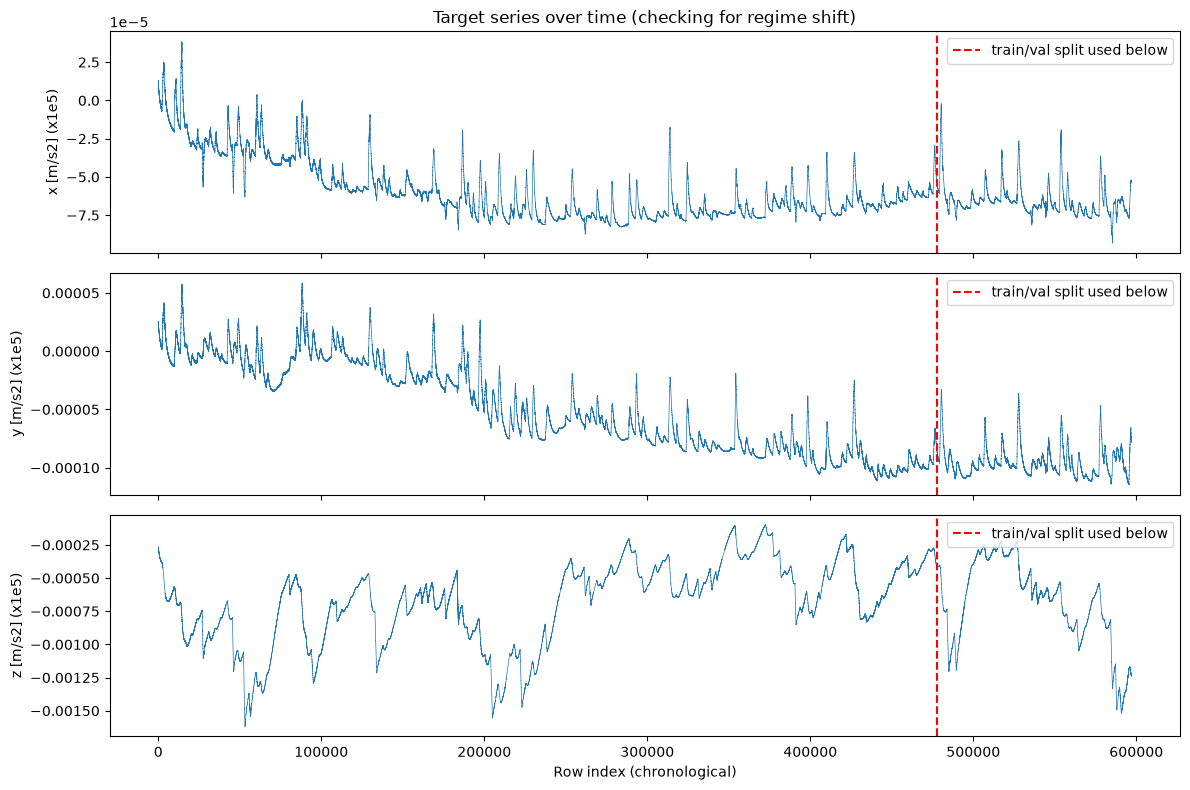


Sequence data shape:
  X sequences: (596934, 30, 29)  (samples, timesteps, features)
  y targets: (596934, 3)  (samples, 3)

----------------------------------------------------------------------
FOLD 1/3  (train=149235, val=149233)
----------------------------------------------------------------------
Epoch 1/10
583/583 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.5240 - mae: 0.5521 - val_loss: 4.6073 - val_mae: 1.6663
Epoch 2/10
583/583 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.4045 - mae: 0.4866 - val_loss: 4.5692 - val_mae: 1.6780
Epoch 3/10
583/583 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3702 - mae: 0.4656 - val_loss: 3.8575 - val_mae: 1.5265
Epoch 4/10
583/583 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3465 - mae: 0.4492 - val_loss: 4.3571 - val_mae: 1.6056
Epoch 5/10
583/583 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3115 - mae: 0.4249 - val_loss: 4.9395 - val_mae: 1.6588
Epoch 6/10
583/583 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2768 - mae: 0.3968 - val_loss: 4.0654 - val

In [39]:
# LSTM Model with Target Scaling, Distribution-Shift Diagnostics, and Walk-Forward Validation

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("LSTM MODEL (SCALED TARGETS + WALK-FORWARD VALIDATION)")
print("="*70)

sequence_length = 30

def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

# Extract nested lists from y_train and convert to numeric array
y_train_extracted = []
for arr in y_train:
    if isinstance(arr[0], list):
        y_train_extracted.append(arr[0])
    else:
        y_train_extracted.append(arr)
y_train_flat = np.array(y_train_extracted, dtype=np.float32)

print(f"y_train_flat shape: {y_train_flat.shape}")

# --- Diagnostic: check for distribution shift across the timeline ---
# Both X and y are scaled using only the training portion of each walk-forward
# fold below, but first visualize the raw target series to confirm whether the
# earlier negative R^2 was driven by a regime shift over time.
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
target_names = ['x [m/s2] (x1e5)', 'y [m/s2] (x1e5)', 'z [m/s2] (x1e5)']
for i in range(3):
    axes[i].plot(y_train_flat[:, i], linewidth=0.5)
    axes[i].axvline(int(len(y_train_flat) * 0.8), color='red', linestyle='--',
                     label='train/val split used below')
    axes[i].set_ylabel(target_names[i])
    axes[i].legend(loc='upper right')
axes[0].set_title("Target series over time (checking for regime shift)")
axes[-1].set_xlabel("Row index (chronological)")
plt.tight_layout()
plt.show()

# --- Build sequences on unscaled data; scaling happens per-fold below to avoid leakage ---
X_seq_raw, y_seq_raw = create_sequences(X_train_combined.values, y_train_flat, sequence_length)

print(f"\nSequence data shape:")
print(f"  X sequences: {X_seq_raw.shape}  (samples, timesteps, features)")
print(f"  y targets: {y_seq_raw.shape}  (samples, 3)")

def build_model(n_features, n_timesteps):
    model = keras.Sequential([
        layers.LSTM(
            64, activation='relu', input_shape=(n_timesteps, n_features),
            return_sequences=False,
            dropout=0.3, recurrent_dropout=0.2,
            kernel_regularizer=regularizers.l2(1e-4),
        ),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(3)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# --- Walk-forward validation: multiple chronological folds instead of one split ---
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_seq_raw), start=1):
    print(f"\n{'-'*70}")
    print(f"FOLD {fold}/{n_splits}  (train={len(train_idx)}, val={len(val_idx)})")
    print(f"{'-'*70}")

    X_fold_train, X_fold_val = X_seq_raw[train_idx], X_seq_raw[val_idx]
    y_fold_train, y_fold_val = y_seq_raw[train_idx], y_seq_raw[val_idx]

    # Fit scalers on this fold's training data only (no leakage across folds)
    n_feat = X_fold_train.shape[-1]
    x_scaler = MinMaxScaler()
    x_scaler.fit(X_fold_train.reshape(-1, n_feat))
    X_fold_train_s = x_scaler.transform(X_fold_train.reshape(-1, n_feat)).reshape(X_fold_train.shape)
    X_fold_val_s = x_scaler.transform(X_fold_val.reshape(-1, n_feat)).reshape(X_fold_val.shape)

    y_scaler = StandardScaler()
    y_fold_train_s = y_scaler.fit_transform(y_fold_train)
    y_fold_val_s = y_scaler.transform(y_fold_val)

    model = build_model(n_feat, sequence_length)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )

    model.fit(
        X_fold_train_s, y_fold_train_s,
        epochs=10,
        batch_size=256,
        validation_data=(X_fold_val_s, y_fold_val_s),
        callbacks=[early_stop],
        verbose=1
    )

    preds_scaled = model.predict(X_fold_val_s, verbose=0)
    preds = y_scaler.inverse_transform(preds_scaled)
    
    print(preds)
    print(y_fold_val)

    r2 = r2_score(y_fold_val, preds)
    mae = mean_absolute_error(y_fold_val, preds)
    mse = mean_squared_error(y_fold_val, preds)

    print(f"\nFold {fold} Results (inverse-transformed to original target scale):")
    print(f"  Val MSE: {mse:.6f}")
    print(f"  Val MAE: {mae:.6f}")
    print(f"  Val R^2:  {r2:.6f}")

    fold_results.append({'fold': fold, 'mse': mse, 'mae': mae, 'r2': r2})

print(f"\n{'='*70}")
print("WALK-FORWARD SUMMARY")
print(f"{'='*70}")
for res in fold_results:
    print(f"  Fold {res['fold']}: R^2 = {res['r2']:.4f}  MAE = {res['mae']:.4f}  MSE = {res['mse']:.4f}")
mean_r2 = np.mean([r['r2'] for r in fold_results])
std_r2 = np.std([r['r2'] for r in fold_results])
print(f"\n  Mean R^2 across folds: {mean_r2:.4f} (+/- {std_r2:.4f})")
print("\nIf R^2 varies wildly or is negative in later folds only, that points to a")
print("regime shift over time rather than a fixable overfitting problem.")


The output is encouraging... the predicted values are within an order of magnitude of the true values